In [82]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
train_info = GraphsTraining()

### Load Pyomo results in

In [11]:
results_pyomo = load_all_pickles("results/pyomo_rl_2026-01-07_23-36-45", recursive=False)[0]
df_reg = Results.collect_data(results_pyomo)
reg = Results.columns_to_lists(df_reg)
reg.keys()

Loaded results/pyomo_rl_2026-01-07_23-36-45/results_full.pkl

Loaded 1 files from results/pyomo_rl_2026-01-07_23-36-45


dict_keys(['Times_Elapsed', 'MSE_odeint', 'MSE_collocation', 'MSE_odeint_test', 'MSE_collocation_test'])

### Load JAX results in

In [107]:
def load_jax_training_df(path, pretraining_time = 0.0) -> pd.DataFrame:
    """
    Load JAX RL run pickles (WITH/NO logging) and return a long-form dataframe with
    time_elapsed, mse_train, mse_test, and seed.

    Args:
        path: Directory containing results_NO_logging.pkl and results_WITH_logging.pkl
        pretraining_time: Default pretraining time (used if times_elapsed doesn't provide it)

    Returns:
        pd.DataFrame: concatenated dataframe across seeds
    """
    path = Path(path)

    with (path / "results_NO_logging.pkl").open("rb") as f:
        results_jax_no_log = pickle.load(f)

    with (path / "results_WITH_logging.pkl").open("rb") as f:
        results_jax_with_log = pickle.load(f)

    training_losses = results_jax_with_log["training_losses"]

    training_jax_df = pd.DataFrame()

    # Keep the same key order you were using
    keys_li = list(results_jax_with_log.keys())

    for i, tl in enumerate(training_losses):
        # get losses after pretraining
        if len(tl) == 2:
            tl = tl[1]
        else:
            tl = tl[0]
        # times elapsed from the NO-log run
        time_elapsed = results_jax_no_log[keys_li[i]]["times_elapsed"]

        # if staged training, override pretraining_time from the recorded value
        pre_t = pretraining_time
        main_t = time_elapsed
        if isinstance(time_elapsed, (list, tuple, np.ndarray)) and len(time_elapsed) > 1:
            pre_t, main_t = float(time_elapsed[0]), float(time_elapsed[1])
        else:
            main_t = float(time_elapsed) - float(pre_t)

        # tl is expected to be [train_losses, test_losses]
        train_losses = tl[0]
        test_losses = tl[1]

        # avoid divide-by-zero if only one point
        denom = max(1, len(train_losses) - 1)
        time_elapsed_per_segment = main_t / denom

        times = np.array([time_elapsed_per_segment * j for j in range(len(train_losses))], dtype=float)
        times += float(pre_t)

        df = pd.DataFrame(
            {
                "time_elapsed": times,
                "mse_train": train_losses,
                "mse_test": test_losses,
                "seed": i,
            }
        )
        training_jax_df = pd.concat([training_jax_df, df], ignore_index=True)

    return training_jax_df

In [108]:
# df = load_jax_training_df("results/jax_rl_runs/jax_rl_2026-01-10_03-44-07/")
# override
training_jax_df = load_jax_training_df("results/jax_rl_runs/jax_rl_2026-01-10_03-44-07/", pretraining_time=7.0)
training_jax_no_pretrain_df = load_jax_training_df("results/jax_rl_runs/jax_rl_2026-01-10_13-29-52/", pretraining_time = 0.0)


In [109]:
training_jax_no_pretrain_df

,time_elapsed,mse_train,mse_test,seed
0,0.000000,2.513148,5.092134,0
1,0.224843,0.942741,4.743115,0
2,0.449686,0.785758,5.043478,0
3,0.674529,0.693988,5.072371,0
4,0.899372,0.617185,5.030133,0
...,...,...,...,...
15010,196.061075,0.012428,0.426490,14
15011,196.257923,0.013240,0.431458,14
15012,196.454772,0.012587,0.433924,14
15013,196.651620,0.012102,0.427906,14


### Load PyTorch results in

In [90]:
fn = "results/pytorch_rl_runs/pytorch_rl_2026-01-09_22-00-20/results_NO_logging.pkl"
with open(fn, 'rb') as file:
    pytorch_jax_no_log = pickle.load(file)
    
fn = "results/pytorch_rl_runs/pytorch_rl_2026-01-09_22-00-20/results_WITH_logging.pkl"
with open(fn, 'rb') as file:
    pytorch_jax_with_log = pickle.load(file)
    

In [27]:
pytorch_jax_with_log

{'2015-01-15': {'mse_train': 0.0874340608716011,
  'mse_test': 0.5594130754470825,
  'time_elapsed': [1.0925812721252441, 16.468852281570435],
  'training_losses': ([1.045965, 0.40201363, 0.19257, 0.124552116, 0.08743406],
   [1.891904, 1.584169, 1.0126545, 0.73034024, 0.5594131])}}

In [24]:
results_jax_with_log["training_losses"][1]

[([2.1612424870778635,
   1.9838899245141233,
   1.779392287141809,
   1.6158937180290727,
   1.5315377107666555,
   1.3734342251747933,
   1.3300981272313444,
   1.1377221708161422,
   1.1125406076869586,
   1.0664311154877903,
   0.9906046364565063],
  [2.563019012077762,
   2.501092493269626,
   2.458319353370433,
   2.418230579640196,
   2.376036439617334,
   2.336671214485077,
   2.2910128141423907,
   2.2555846010998146,
   2.231719698697347,
   2.220075602227192,
   2.1849886533653846])]

In [74]:
fn = "results/pyomo_rl_2026-01-07_23-36-45/results_full.pkl"
#fn = 'results/convergence_2024-09-02_17-22-56_full.pkl'
pyomo_convergence = Results.load_results(fn)

keys = {k:k for k in list(pyomo_convergence.values())[0].keys()}
pyomo_df = Results.collect_data(pyomo_convergence, keys)

df = pyomo_df.drop(columns=['result']).reset_index(drop=True)
list_cols = df.columns.tolist()

N_SEEDS = 10  # <-- set this

def seed_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.repeat(np.arange(n_seeds), n_steps))

def step_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.tile(np.arange(n_steps), n_seeds))

df['seed'] = df[list_cols[0]].apply(lambda xs: seed_labels_chunked(xs, N_SEEDS))

pyomo_long = df.explode(list_cols + ['seed'], ignore_index=True).rename(columns = {"times_elapsed":"time_elapsed", "mse_coll_ode" : "mse_train", "mse_coll_ode_test":"mse_test"})


In [75]:
training_jax_df.head(1)

,time_elapsed,mse_train,mse_test,seed
0,7.0,3.343908,2.905199,0


In [123]:
pyomo_long = pyomo_long[pyomo_long["time_elapsed"] <= 9.0]

comparison_dfs = {
    "Pyomo": pyomo_long,
    "JAX": training_jax_df,
    "JAX_no_pretrain": training_jax_no_pretrain_df,}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:702: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


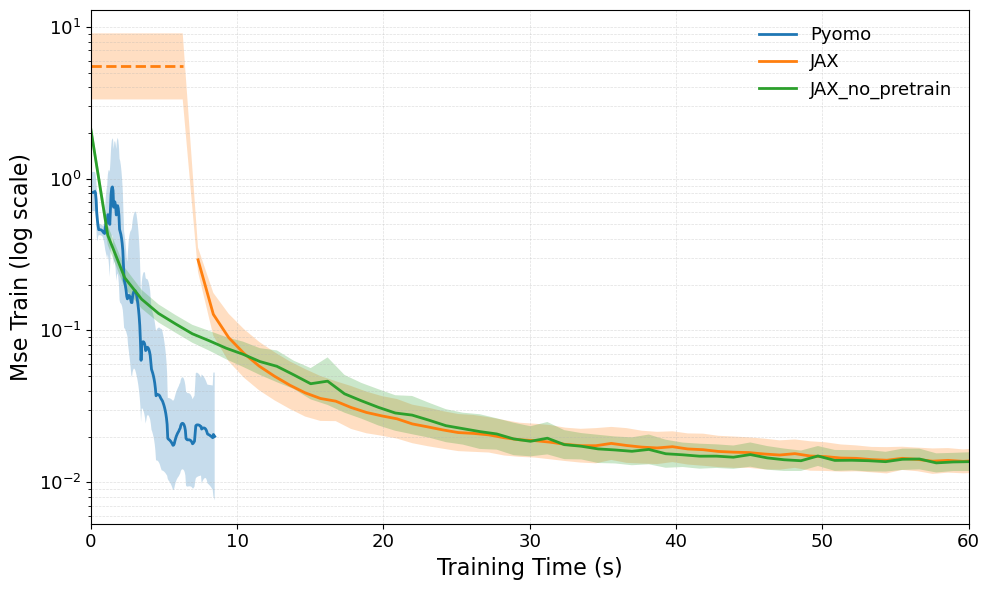

<Axes: xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [124]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 60)
)

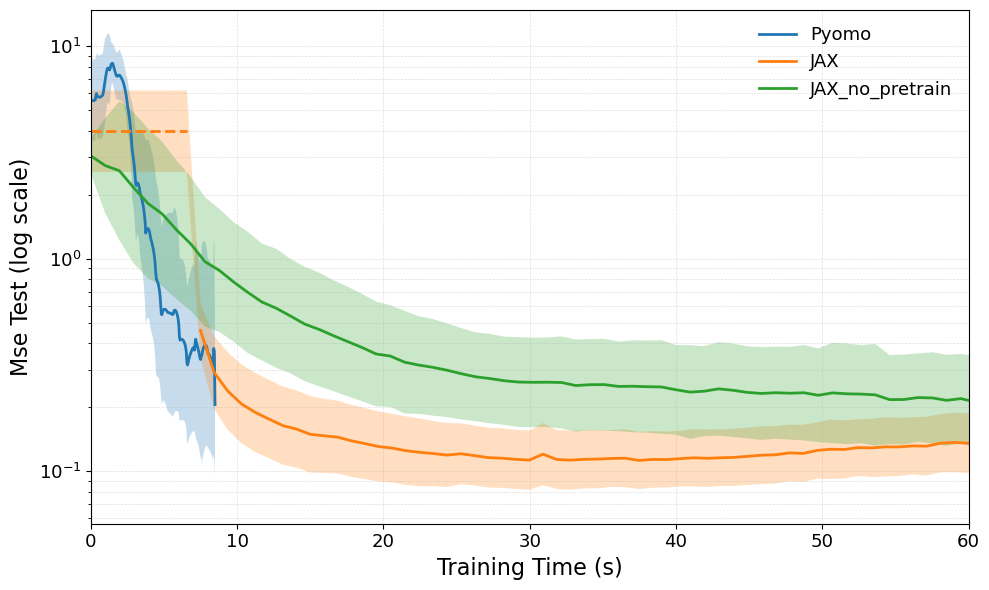

<Axes: xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [125]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=0.5,
    xlim =(0, 60)
)

In [43]:
list(pyomo_df["times"])

[array([ 0.        ,  0.23630653,  0.47261307,  0.7089196 ,  0.94522614,
         1.18153267,  1.4178392 ,  1.65414574,  1.89045227,  2.1267588 ,
         2.36306534,  2.59937187,  2.83567841,  3.07198494,  3.30829147,
         3.54459801,  3.78090454,  4.01721107,  4.25351761,  4.48982414,
         4.72613068,  4.96243721,  5.19874374,  5.43505028,  5.67135681,
         5.90766335,  6.14396988,  6.38027641,  6.61658295,  6.85288948,
         7.08919601,  7.32550255,  7.56180908,  7.79811562,  8.03442215,
         8.27072868,  8.50703522,  8.74334175,  8.97964828,  9.21595482,
         9.45226135,  9.68856789,  9.92487442, 10.16118095, 10.39748749,
        10.63379402, 10.87010056, 11.10640709, 11.34271362, 11.57902016])]